# **ROC Curve (Receiver Operating Characteristic)**

## **1. Introduction**
The **ROC Curve** is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It is one of the most important evaluation metrics for checking any classification model's performance.

It is a **probability curve** that plots the **TPR (True Positive Rate)** against the **FPR (False Positive Rate)** at various threshold settings.

## **2. Key Metrics Involved**
To understand ROC, we must first understand the two metrics it uses:

### **A. True Positive Rate (TPR) / Recall / Sensitivity**
TPR tells us what proportion of the positive class was correctly identified.

$$TPR = \\frac{TP}{TP + FN}$$

### **B. False Positive Rate (FPR)**
FPR tells us what proportion of the negative class was incorrectly identified as positive.

$$FPR = \\frac{FP}{FP + TN} = 1 - Specificity$$

## **3. How the ROC Curve is Created**
Most machine learning models (like Logistic Regression) don't just output a class (0 or 1), but a **probability** (e.g., 0.8).

1. **Thresholding**: We choose a threshold (default is usually 0.5) to decide the class. If probability > 0.5, it's Class 1; else Class 0.
2. **Varying Thresholds**: In ROC analysis, we vary this threshold from **0.0 to 1.0**.
3. **Plotting**: For every threshold, we calculate the (FPR, TPR) pair and plot it on a graph.
4. **Connecting the Dots**: Joining these points gives us the ROC Curve.

## **4. AUC (Area Under the Curve)**
**AUC** represents the degree or measure of separability. It tells us how much the model is capable of distinguishing between classes.

- **AUC = 1**: The model is perfect. It can perfectly distinguish between all Positive and Negative points.
- **0.5 < AUC < 1**: There is a high chance that the classifier will be able to distinguish the positive class values from the negative class values.
- **AUC = 0.5**: The model has no capacity to distinguish between positive and negative classes (Random Guessing).
- **AUC = 0**: The model is reciprocating the classes (predicting 0 as 1 and vice-versa).

## **5. Geometric Intuition**
Imagine the probability distributions of your two classes (Positive and Negative):

- **No Overlap**: If the distributions don't overlap at all, AUC is **1.0**. We can find a threshold that perfectly separates them.
- **Overlap**: As the distributions overlap, the ROC curve moves toward the diagonal line ($y=x$), and AUC decreases.
- **Complete Overlap**: If the distributions are identical, AUC is **0.5**.

> **Summary**: A higher AUC indicates that the model is better at predicting 0s as 0s and 1s as 1s.

## **6. Python Example using Scikit-Learn**
```python
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# y_test: true labels, y_probs: predicted probabilities
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Random guessing line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
```

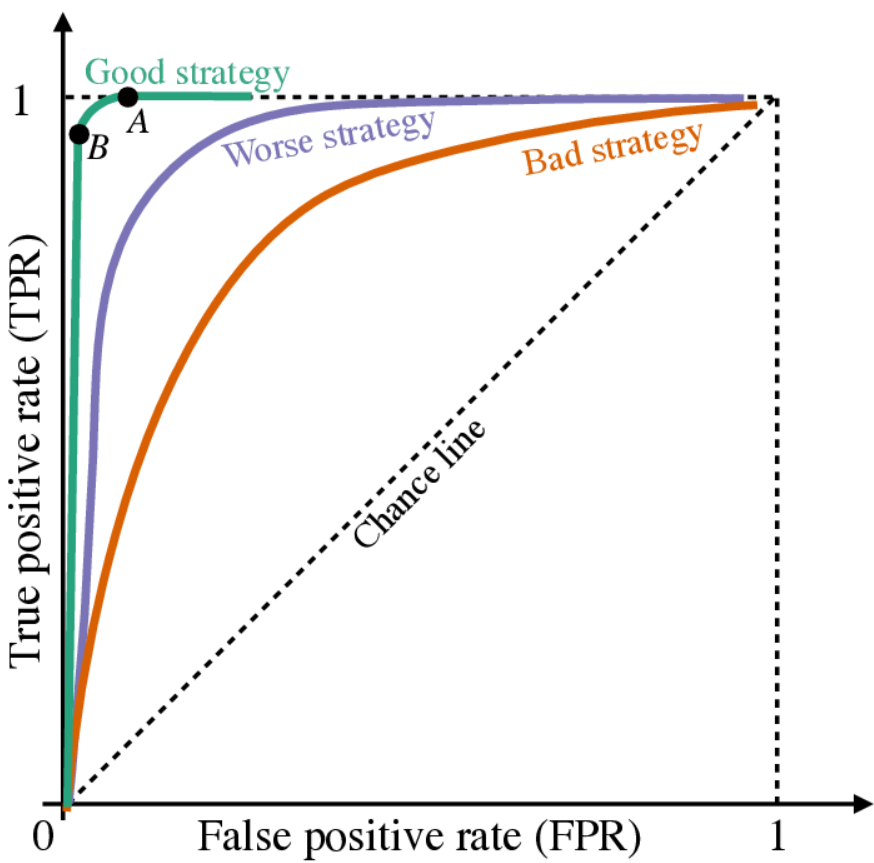

# AUC-ROC Curve: A Detailed Guide

## 1. What is an ROC Curve?
The **Receiver Operating Characteristic (ROC)** curve is a plot that shows the performance of a classification model at all classification thresholds. This curve plots two parameters:
*   **True Positive Rate (TPR)**
*   **False Positive Rate (FPR)**

### Mathematical Definitions:
*   **True Positive Rate (TPR)** is a synonym for **Recall**:
    $$TPR = \frac{TP}{TP + FN}$$
*   **False Positive Rate (FPR)**:
    $$FPR = \frac{FP}{FP + TN}$$



## 2. Understanding AUC (Area Under the Curve)
**AUC** stands for "Area under the ROC Curve." That is, AUC measures the entire two-dimensional area underneath the entire ROC curve (think integral calculus) from $(0,0)$ to $(1,1)$.

### Interpretation of AUC Values:
- **AUC = 1.0**: Perfect classifier (all positives ranked higher than all negatives).
- **0.9 < AUC < 1.0**: Excellent separability.
- **0.7 < AUC < 0.8**: Acceptable/Good separability.
- **AUC = 0.5**: No better than random guessing (represented by the diagonal line).
- **AUC < 0.5**: Worse than random (the model is effectively "flipping" labels).



## 3. The Probabilistic Intuition
AUC has a beautiful probabilistic interpretation:
> **AUC represents the probability that a random positive instance will be ranked higher by the model than a random negative instance.**



## 4. Why Use AUC-ROC instead of Accuracy?
1.  **Scale-Invariant**: It measures how well predictions are ranked, rather than their absolute values.
2.  **Threshold-Invariant**: It measures the quality of the model's predictions irrespective of what classification threshold is chosen. 
3.  **Handles Class Imbalance**: While not as robust as the Precision-Recall curve for extreme imbalance, it is far more informative than accuracy when classes are skewed.
